# Детектирование автоматизированного сбора данных по событиям куки

**Метрика:** Precision при Recall ≥ 0.70, считается `metric.py` из условия.
**Данные:** 11 091 куки в train (6–19 апреля), 4 909 в test (20–26 апреля), 328 905 событий.
**Результат:** P@R70 0.8937 ±0.0025 против 0.7381 у baseline из ~50 агрегатов.

---

## Подход — коротко

- **Готовых признаков нет, есть лог событий.** Собрано 479 признаков в 18 блоках: ритм
  и микроструктура интервалов, сессии, навигация, курсор, User-Agent, последовательность
  событий, популярность открытых объявлений — раздел 6.
- **12.4 % событий датированы позже `window_end_ts`** и отбрасываются: условие требует,
  чтобы признак был доступен на момент конца окна — раздел 2.
- **Метрика шумная** — одна точка PR-кривой на ~900 позитивах, разброс по дням до 0.15.
  Поэтому оптимизация шла по PR-AUC, а блок принимался только при одновременном росте
  PR-AUC, неухудшении P@R70 и неухудшении forward-chaining — раздел 4.
- **Валидация тройная:** случайный K-fold, forward-chaining по дням и `src.strict`,
  который пересобирает матрицу признаков заново по дням до среза. Третий протокол
  необходим: он поймал признак, завышавший метрику на 0.11 — раздел 4.
- **Модель — один LightGBM** с бэггингом по 10 сидам в ранговом пространстве. Ансамбль
  трёх семейств и подбор гиперпараметров измерены и отвергнуты — разделы 9 и 10.

Использованы только open-source библиотеки, всё считается локально, внешних API и
языковых моделей нет. Все сиды зафиксированы, версии — в `requirements.txt`.

In [1]:
import sys, platform, hashlib, json
import numpy as np, pandas as pd

sys.path.insert(0, ".")
from src import config, data, features, plots, report, validate
from src.model import ModelSpec, estimate_rounds, fit_predict, rank_average
from src.pipeline import build_dataset, write_submission

plots.use_style()
pd.set_option("display.width", 160)

print("python", platform.python_version())
for module in ("pandas", "numpy", "sklearn", "lightgbm", "catboost", "xgboost"):
    print(module, __import__(module).__version__)
print("seed", config.SEED)

python 3.14.7
pandas 2.3.3
numpy 2.5.2
sklearn 1.9.0
lightgbm 4.7.0
catboost 1.2.10
xgboost 3.3.0
seed 42


## 1. Данные и границы окон

Одна строка train/test — одна кука с суточным окном наблюдения. Окна train и test
идут подряд и не пересекаются, поэтому любая валидация обязана быть согласована со
временем.

findfont: Failed to find font weight semibold, now using 700.


train (11091, 5)  test (4909, 4)
доля положительного класса: 0.0811  (899 из 11091)
train окна: 2026-04-06 .. 2026-04-19
test  окна: 2026-04-20 .. 2026-04-26
пересечение cookie_id: 0
длительность окна, суток: [np.int64(1)]


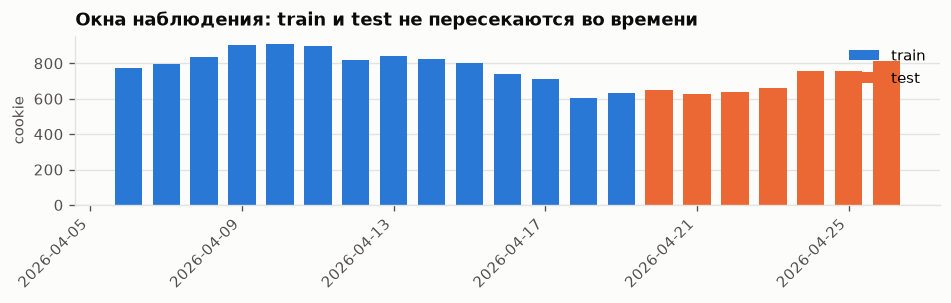

In [2]:
train, test = data.load_splits()
meta = pd.concat([train.drop(columns=["target"]), test], ignore_index=True)

print(f"train {train.shape}  test {test.shape}")
print(f"доля положительного класса: {train.target.mean():.4f}  ({int(train.target.sum())} из {len(train)})")
print(f"train окна: {train.window_start_ts.min().date()} .. {train.window_start_ts.max().date()}")
print(f"test  окна: {test.window_start_ts.min().date()} .. {test.window_start_ts.max().date()}")
print(f"пересечение cookie_id: {len(set(train.cookie_id) & set(test.cookie_id))}")
print(f"длительность окна, суток: {sorted((meta.window_end_ts - meta.window_start_ts).dt.days.unique())}")

plots.window_timeline(train, test);

## 2. События и фильтр окна

`platform` приходит в разном регистре (`WEB`/`Web`/`web`, `ANDROID`/`Android`/`android`,
`iphone`/`IOS`/`iOS`/`ios`) — приводится к четырём значениям `web`, `desktop`,
`android`, `ios`.

Главное: **12.4 % событий датированы позже конца окна наблюдения**. До начала окна
событий нет вообще. Условие задачи прямо запрещает признаки, недоступные на момент
`window_end_ts`, поэтому такие строки отбрасываются до построения любых признаков.

In [3]:
events_raw = data.load_events()
print(f"всего событий: {len(events_raw)}, кук в событиях: {events_raw.cookie_id.nunique()}")
print("\nтипы событий:")
print(events_raw.event_name.value_counts().to_string())
print("\nплатформы после нормализации:", sorted(events_raw.platform.cat.categories))
print("\nдоля пропусков по полям:")
print((events_raw.isna().mean() * 100).round(1).to_string())

всего событий: 328905, кук в событиях: 16000

типы событий:
event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081

платформы после нормализации: ['android', 'desktop', 'ios', 'web']

доля пропусков по полям:
cookie_id         0.0
event_ts          0.0
eid               0.0
event_name        0.0
platform          0.0
user_agent        0.0
item_id          34.8
item_category    10.0
item_location     7.2
seller_type      40.7
search_query     69.5
search_page      69.5
pointer_x        67.0
pointer_y        67.0


In [4]:
bounds = meta.set_index("cookie_id")
late = events_raw.event_ts > events_raw.cookie_id.map(bounds.window_end_ts)
early = events_raw.event_ts < events_raw.cookie_id.map(bounds.window_start_ts)
print(f"событий позже window_end_ts: {late.mean():.4%}")
print(f"событий раньше window_start_ts: {early.mean():.4%}")

events = data.clip_to_window(events_raw, meta)
data.assert_no_future_leak(events, meta)
print(f"\nпосле фильтра: {len(events)} событий ({len(events) / len(events_raw):.2%}), кук {events.cookie_id.nunique()}")
print("инвариант отсутствия утечки: пройден")

событий позже window_end_ts: 12.3777%
событий раньше window_start_ts: 0.0000%



после фильтра: 288126 событий (87.60%), кук 16000
инвариант отсутствия утечки: пройден


## 3. Как выглядит положительный класс

Портрет складывается из ритма, широты обхода и отсутствия «человеческих» действий.

In [5]:
labelled = events.merge(train[["cookie_id", "target"]], on="cookie_id")
gaps = labelled.groupby("cookie_id").event_ts.diff().dt.total_seconds()

summary = pd.DataFrame({
    "медианный интервал между событиями, с": gaps.groupby(labelled.target).median(),
    "максимальная страница выдачи": labelled.groupby("target").search_page.max(),
    "уникальных локаций на куку": labelled.groupby(["target", "cookie_id"]).item_location.nunique().groupby("target").mean(),
    "доля photo_swipe": labelled.groupby("target").event_name.apply(lambda s: (s == "photo_swipe").mean()),
    "доля favorite_add": labelled.groupby("target").event_name.apply(lambda s: (s == "favorite_add").mean()),
    "доля login": labelled.groupby("target").event_name.apply(lambda s: (s == "login").mean()),
}).T
summary.columns = ["человек (0)", "бот (1)"]
summary.round(3)

,человек (0),бот (1)
"медианный интервал между событиями, с",46.000,14.000
максимальная страница выдачи,33.000,63.000
уникальных локаций на куку,5.882,9.790
доля photo_swipe,0.123,0.070
доля favorite_add,0.066,0.027
доля login,0.021,0.008


In [6]:
web = labelled[labelled.platform.astype(str).isin(["web", "desktop"])]
coverage = web.groupby("target").pointer_x.apply(lambda s: s.notna().mean())
print("доля событий с координатами курсора (только web/desktop):")
print(f"  человек: {coverage[0]:.3f}")
print(f"  бот:     {coverage[1]:.3f}")
print("\nна android и ios координат нет ни у кого — поэтому признак считается отдельно по платформам")

доля событий с координатами курсора (только web/desktop):
  человек: 0.662
  бот:     0.330

на android и ios координат нет ни у кого — поэтому признак считается отдельно по платформам


## 4. Метрика и схема валидации

`P@R70` берёт максимум precision среди порогов с recall ≥ 0.70. На выборке с ~900
позитивами это решение одной точки на кривой, и оно очень шумное. Ниже — одна и та же
модель, оценённая по случайным фолдам и по дням: целевая метрика гуляет в пределах
0.15, тогда как ROC-AUC держится в узком коридоре.

Отсюда рабочее правило: **оптимизируем PR-AUC, решение принимаем по связке метрик**,
и ни один блок не принимается по улучшению P@R70 меньше разброса по сидам.

Протоколов три, и третий появился не сразу.

1. **Случайный K-fold**, 5 фолдов × 5 сидов — основной, даёт максимум позитивов в OOF.
2. **Forward-chaining по дням** — обучение на днях до `k`, оценка на дне `k`. Ловит
   признаки, которые описывают популяцию конкретного дня, а не куку.
3. **`src.strict`** — матрица признаков **пересобирается заново** по дням до среза, и
   только потом оцениваются дни после. Отличие от второго существенное: forward-chaining
   режет матрицу, построенную один раз по всему train, поэтому словари, TF-IDF,
   перцентильные эталоны и любые популяционные статистики в нём посчитаны с участием
   будущих дней. Для скрытого теста это недоступно.

Третий протокол пришлось добавить после того, как первая версия блока популярности
дала +0.110 P@R70 по первому протоколу и +0.028 по третьему. Причина была не в признаке,
а в его асимметрии: аудитория считалась счётчиком по фиксированному пулу train, из-за
чего train-кука сравнивалась со своими современниками, а test-кука — с куками других
недель, и сам счётчик в пулах разного размера значит разное. После замены счётчика
перцентилем внутри общего пула разрыв между протоколами — 0.007.

матрица признаков: 11091 кук × 479 признаков


P@R70 по случайным фолдам: [0.915 0.902 0.911 0.858 0.828]
P@R70 по дням forward-chain: [0.929 0.907 0.944 0.857 0.906 0.792 0.882]


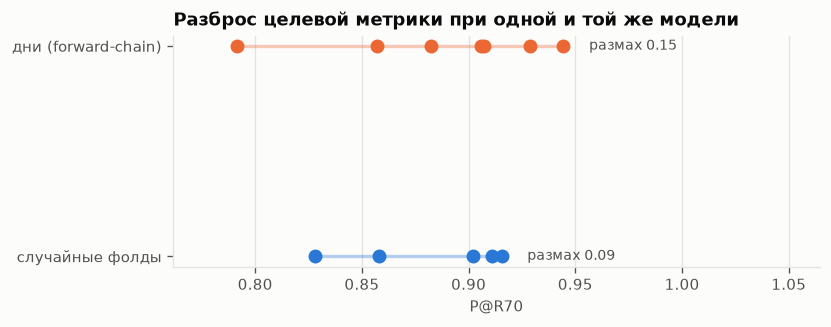

In [7]:
from sklearn.model_selection import StratifiedKFold

dataset = build_dataset()
x, y = dataset.x_train, dataset.y_train
print(f"матрица признаков: {x.shape[0]} кук × {x.shape[1]} признаков")

probe = ModelSpec("lgb", n_rounds=400)
fold_scores = []
for train_idx, valid_idx in StratifiedKFold(5, shuffle=True, random_state=config.SEED).split(x, y):
    pred = fit_predict(probe, x.iloc[train_idx], y.iloc[train_idx], x.iloc[valid_idx])
    fold_scores.append(validate.precision_at_recall(y.iloc[valid_idx], pred))

day_scores = []
days = sorted(dataset.day_index.unique())
for day in days[7:]:
    mask_tr, mask_va = dataset.day_index < day, dataset.day_index == day
    pred = fit_predict(probe, x[mask_tr], y[mask_tr], x[mask_va])
    day_scores.append(validate.precision_at_recall(y[mask_va], pred))

print("P@R70 по случайным фолдам:", np.round(fold_scores, 3))
print("P@R70 по дням forward-chain:", np.round(day_scores, 3))
plots.metric_noise(fold_scores, day_scores);

## 5. Baseline

Первый ориентир — около 50 простых агрегатов: счётчики событий, доли типов, базовые
квантили интервалов, число уникальных категорий/локаций/объявлений, средняя и
максимальная страница выдачи, доли платформ, возраст куки.

In [8]:
BASELINE_PATTERN = (
    r"^(n_events|cnt_|rate_|dt_q|dt_std|dt_min|span_h|events_per_h|item_category_nuniq"
    r"|item_location_nuniq|item_id_nuniq|search_query_nuniq|page_mean|page_max|plat_"
    r"|pointer_coverage|ptr_x_std|ptr_y_std|cookie_age_days)"
)
x_baseline = x.filter(regex=BASELINE_PATTERN)
folds = list(StratifiedKFold(config.N_FOLDS, shuffle=True, random_state=config.SEED).split(x, y))

baseline_spec = ModelSpec("lgb", n_rounds=estimate_rounds("lgb", x_baseline, y, folds[:3]))
baseline = validate.repeated_cv(baseline_spec, x_baseline, y, n_seeds=3)
print(validate.format_report(f"baseline ({x_baseline.shape[1]} признаков)", baseline))

baseline (46 признаков)      P@R70 0.7381±0.0046  ROC 0.9240  PR 0.7699  R@FPR1 0.6225


## 6. Признаки: 18 блоков

| блок | что описывает |
|---|---|
| объём и микс | счётчики и доли 10 типов событий, активные часы, ночная доля |
| переходы | доли топ-25 биграмм, self-loop, энтропия переходов |
| тайминги | квантили интервалов, IQR, MAD, CV, энтропия log-интервала, burstiness, Fano, автокорреляция |
| гранулярность интервалов | число уникальных интервалов, их доля, «круглые» интервалы |
| сессии (gap > 30 мин) | число сессий, событий и длительность на сессию, доля крупнейшей |
| разнообразие контента | nunique и энтропия по категориям, локациям, объявлениям, запросам |
| пагинация | средняя/максимальная страница, длина возрастающих пробегов, страниц на запрос |
| курсор | покрытие, разброс, шаг, скорость |
| геометрия курсора | прямолинейность, углы поворота, квантили скорости, привязка к сетке, квадранты |
| платформа и UA | доли платформ, семейство браузера, headless, редкость UA |
| dwell | время до следующего события по типам |
| навигация | частота смены категории/локации/запроса, длины пробегов, воронка |
| профиль каталога | доли локаций, категорий и запросов |
| популярность объявлений | аудитория открытых объявлений перцентилем в общем пуле, свой вклад вычтен |
| относительно популяции | dwell против медианы по типу события, глубина страницы против медианы по тому же запросу |
| структура item_id | разброс, диапазон, монотонность обхода |
| последовательность | TF-IDF n-грамм событий и «событие + корзина интервала» → SVD |
| временной ряд | поток событий как точечный процесс: корзины 1/5/30 мин (пик, Fano, занятость, энтропия, пробеги), gzip-сжимаемость потоков действий и каталога, круговая концентрация времени суток, форма распределения интервалов в логарифме, перестановочная энтропия |
| относительные ранги | перцентиль внутри своей платформы |

Блоки, посчитанные отдельно по платформам (`mob_`, `web_`, `webp_`), — ответ на то,
что платформы заполняют разные поля: интервалы на мобильном и на вебе физически
разные измерения.

In [9]:
BLOCKS = {
    "объём и микс": r"^(n_events|cnt_|rate_|ratio_|n_active_hours|events_per_active_hour|hour_entropy|night_rate)",
    "переходы": r"^(bg_|n_bigrams_uniq|bigram_entropy|self_loop_rate)",
    "тайминги": r"^(dt_|span_h|events_per_h)",
    "гранулярность dt": r"^dtg_",
    "сессии": r"^(sess_|n_sessions)",
    "контент": r"^(item_|search_query_|seller_)",
    "пагинация": r"^(page_|queries_nuniq|pages_per_query|query_repeat_rate|query_len_mean)",
    "курсор": r"^(ptr_|pointer_coverage)",
    "геометрия курсора": r"^ptrd_",
    "платформа и UA": r"^(plat_|n_platforms|platform_entropy|n_user_agents|ua|uafam_|dominant_platform)",
    "dwell": r"^dwell_",
    "навигация": r"^(nav_|funnel_|swipe_run_max)",
    "профиль каталога": r"^(shloc_|shcat_|shq_)",
    "популярность объявлений": r"^pop_",
    "относительно популяции": r"^crowd_",
    "структура item_id": r"^idst_",
    "последовательность": r"^(seqo_|seqp_)",
    "временной ряд": r"^(b1m_|b5m_|b30m_|cmp_|tod_|gap_)",
    "по платформам": r"^(mob_|web_|webp_)",
    "относительные ранги": r"^rel_plat_",
    "мета куки и окна": r"^(cookie_|window_dow|first_event_offset_h|last_event_offset_h|window_coverage)",
}
sizes = pd.Series({name: x.filter(regex=pattern).shape[1] for name, pattern in BLOCKS.items()})
covered = set().union(*(set(x.filter(regex=p).columns) for p in BLOCKS.values()))
print(f"всего признаков: {x.shape[1]}, не отнесены ни к одному блоку: {len(set(x.columns) - covered)}")
sizes.sort_values(ascending=False).to_frame("признаков")

всего признаков: 479, не отнесены ни к одному блоку: 2


,признаков
профиль каталога,95
по платформам,64
временной ряд,34
объём и микс,30
переходы,28
платформа и UA,27
геометрия курсора,26
тайминги,24
относительные ранги,20
контент,20


## 7. Вклад блоков

Leave-one-block-out по всем 22 семействам полного набора (3 сида): блок удаляется,
модель переобучается, разница читается как вклад блока. Результаты берутся из журнала
экспериментов, воспроизводятся командой `python -m src.ablation`.

,Δ P@R70
block,
popularity,-0.0931
pointer_deep,-0.0174
content,-0.0109
pointer,-0.0074
window,-0.0072
dt_granularity,-0.0064
catalog_shares,-0.0059
crowd_relative,-0.0057
client,-0.0053


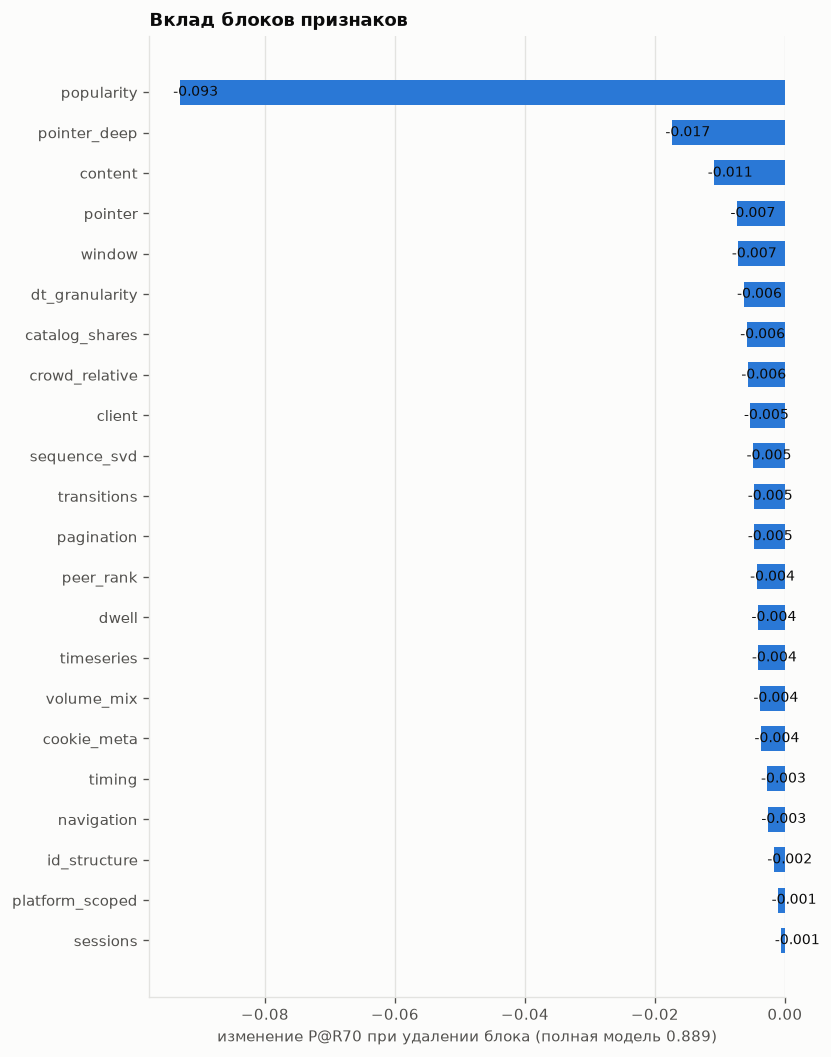

In [10]:
history = report.load()
# Имена прогонов повторяются — абляция гонялась и на раннем наборе тоже, — поэтому
# берём последний прогон каждого блока: он относится к текущему набору признаков.
ablation_rows = history[history.experiment.str.startswith("ablation_")].drop_duplicates(
    subset="experiment", keep="last"
)
full_score = float(ablation_rows.loc[ablation_rows.experiment == "ablation_full", "P@R70"].iloc[0])
deltas = (
    ablation_rows[ablation_rows.experiment != "ablation_full"]
    .assign(block=lambda f: f.experiment.str.replace("ablation_drop_", "", regex=False))
    .set_index("block")["P@R70"]
    - full_score
)
plots.ablation(deltas, full_score)
deltas.sort_values().round(4).to_frame("Δ P@R70")

Популярность объявлений отрывается от всего остального в пять раз. Механизм виден
прямо в данных: у объявлений, которых касался бот, 51 % аудитории — боты, при доле ботов
8 % среди кук. 899 ботов топчутся по пулу из 6957 объявлений, а 10192 человека размазаны
по 45538. Объявление с аудиторией ровно в одну куку встречается у человека в 38 %
случаев, у бота — в 14 %. Остальная матрица описывает, *как* кука себя ведёт; этот блок
описывает, *куда* она ходит относительно остальных.

Следом идёт курсор, и работает он не формой траектории, а самим фактом наличия
координат: на web/desktop поле заполнено у 66 % событий людей и у 33 % событий ботов.
При этом координат нет у 72 % ботов, поэтому одним этим блоком recall 0.70 не набрать:
он вычищает верх ранжирования, а саму полноту обеспечивают мобильные и бескурсорные
куки.

Третий по величине шаг сессии виден не в абляции, а в истории: скриптовые HTTP-клиенты
(curl, Scrapy, node-fetch, python-requests, python-urllib3, Go-http-client) до этого
сваливались в общую корзину `other` вместе с нативным приложением — самое сильное
положительное свидетельство усреднялось со своей противоположностью. Разделение дало
+0.012 P@R70 одним шагом.

## 8. Где модель проигрывает

Метрика внутри подгруппы сама по себе обманчива: она падает там, где мало позитивов,
а не там, где плохо ранжирование. Честный замер — потолок: заморозить модель,
переставить скоры внутри подгруппы в идеальный порядок, сохранив её собственные
значения, и пересчитать метрику глобально. Так видно, сколько ошибки реально можно
вернуть из этой подгруппы.

| подгруппа | потолок P@R70 |
|---|---|
| web | +0.095 |
| без курсора | +0.066 |
| много событий (>23) | +0.061 |
| mobile | +0.027 |
| мало событий (≤8) | +0.009 |

Низкий P@R70 на мобильном — эффект базовой доли: 6.0 % ботов против 9.9 % на вебе.
Основной остаток ошибки лежит на вебе, причём в той его половине, где курсор **есть**:
там 6.2 % позитивов против 18.0 % у бескурсорного веба.

lgb: cached oof_lgb_default_5seeds_479f_0839370a3f2b_9e356aed.npy


cat: cached oof_cat_default_5seeds_479f_0839370a3f2b_8da77982.npy


xgb: cached oof_xgb_default_5seeds_479f_0839370a3f2b_103695d7.npy
полный набор (479 признаков): p_at_r70 0.8938  roc_auc 0.9529  pr_auc 0.8419  recall_at_fpr1 0.7508


,regime,n,bots,p_at_r70,roc_auc,pr_auc,recall_at_fpr1
0,web с курсором,4046,251,0.8478,0.9772,0.8563,0.8127
1,web без курсора,1871,337,0.9478,0.9538,0.9099,0.7240
2,mobile,5174,311,0.5533,0.9088,0.7262,0.6206
3,много событий (>23),2707,389,0.9424,0.9766,0.9347,0.7326
4,мало событий (≤8),3900,150,0.3153,0.8984,0.5934,0.5067


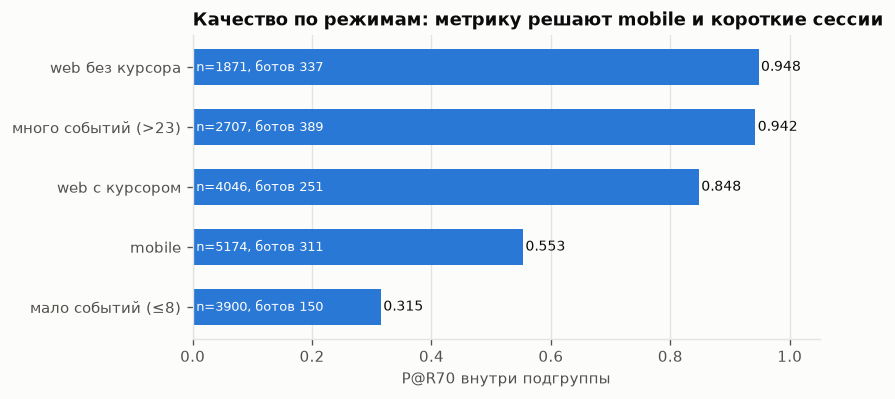

In [11]:
from src.ensemble import KINDS, family_oof

# OOF каждого семейства считается один раз и кешируется. Здесь нужен LightGBM,
# в разделе 10 те же массивы уходят в поиск весов — второго обучения не будет.
oof_by_kind, _, specs = family_oof(KINDS, seeds=config.N_SEEDS, tuned=False, refresh=False)
spec, oof_final = specs["lgb"], oof_by_kind["lgb"]
scores = validate.score(y, oof_final)
print(f"полный набор ({x.shape[1]} признаков): " + "  ".join(f"{k} {v:.4f}" for k, v in scores.items()))

mobile = x[["plat_android", "plat_ios"]].sum(axis=1) > 0.5
has_cursor = x["pointer_coverage"].fillna(0) > 0
regime_masks = {
    "web с курсором": ~mobile & has_cursor,
    "web без курсора": ~mobile & ~has_cursor,
    "mobile": mobile,
    "много событий (>23)": x["n_events"] > 23,
    "мало событий (≤8)": x["n_events"] <= 8,
}
regime_frame = pd.DataFrame([
    {"regime": name, "n": int(mask.sum()), "bots": int(y[mask.to_numpy()].sum()),
     **validate.score(y[mask.to_numpy()], oof_final[mask.to_numpy()])}
    for name, mask in regime_masks.items()
])
plots.regimes(regime_frame)
regime_frame.round(4)

## 9. Что было отвергнуто

| гипотеза | результат |
|---|---|
| граф совместных просмотров объявлений | рёбра слишком редкие: косинус к ближайшему соседу по мешку `item_id` даёт AUC 0.59. Но **степень вершины** — сколько других кук открывали объявление — оказалась сильнейшим признаком набора, см. блок популярности |
| счётчик аудитории по фиксированному пулу train | +0.110 P@R70 по обычному протоколу и +0.028 по строгому: train-кука сравнивалась с современниками, test-кука нет, а сырой счётчик в пулах разного размера значит разное. Исправлено перцентилем в общем пуле |
| аудитория, нормированная на категорию | AUC 0.775 — тот же сигнал, что и ненормированная 0.777 |
| возраст объявления и аудитория на час экспозиции | 0.59 и 0.657 на своей неделе, но на чужой когорте вторая даёт 0.344 — длина окна наблюдения объявления зависит от того, сколько его наблюдал пул |
| со-просмотры одного объявления в окне 5 и 60 минут | AUC 0.50 и 0.58, пачечной структуры нет |
| сходство поведения с ближайшим соседом (TF-IDF последовательности событий) | лучший столбец AUC 0.60, а счётчик точных двойников работает в обратную сторону: у людей их больше |
| суточный профиль против популяции (KL, total variation) | AUC 0.45–0.51; окна длиной сутки, поэтому и вся дневная структура вырождена |
| Markov-surprise под популяционной матрицей переходов | глобально AUC 0.62 инвертированно, но знак переворачивается между web (0.725) и mobile (0.552), а блок биграмм это уже несёт |
| выравнивание по секундам (`second == 0`, `% 5`, `% 10`) | AUC 0.52–0.55; в таймстемпах вообще нет долей секунды |
| дубли строк в логе событий как признак | 4297 точных дублей у 2362 кук, доля даёт AUC 0.549, счётчик 0.562 |
| `eid` | десять значений 100…900, второе написание `event_name` |
| домножение вероятностей (prior correction после андерсэмплинга) | преобразование строго монотонно, метрика ранговая: P@R70, ROC-AUC и PR-AUC совпадают до шестого знака. Изменить их домножением можно только обрезкой, а она создаёт группы равных значений и разрушает метрику: 0.8077 → 0.0986 |
| развёртка `scale_pos_weight` (3, 6, 11.3, 25) | лучшая точка — штатный `is_unbalance`; 25 даёт выше P@R70, но ниже PR-AUC |
| перцентильные ранги внутри окна-дня | лучший результат по случайному CV (0.7953) и падение forward-chaining 0.7705 → 0.7369: ранг внутри дня описывает популяцию дня, а не куку |
| `window_day_index` | окна test целиком позже train (среднее 6.19 против 17.18), любое разбиение по абсолютному индексу дня не переносится |
| отбор топ-200 признаков по gain | PR-AUC 0.7950 против 0.7949 — в пределах шума |
| `captcha_shown` как правило | встречается у 0.2 % ботов и 0 % людей, работать не с чем |
| совпадающие метки времени как признак параллельных запросов | 1.8 % у ботов против 2.2 % у людей, различий нет |
| несоответствие User-Agent и платформы | в данных отсутствует: мобильный UA всегда приходит с мобильной платформы |
| отдельная модель-специалист по мобильному трафику | внутри подгруппы PR-AUC 0.6160 против 0.6327 у общей модели: 311 позитивов не тянут отдельную модель, а веб-строки, которые специалист выбрасывает, чему-то переносимому его учили |
| перенос порядка внутри мобильной подгруппы и стекинг поверх двух скоров | каждый вариант меняет P@R70 в пределах собственного шума и теряет PR-AUC |
| мобильная копия блока временного ряда | у мобильной куки почти нет немобильных событий, копия повторяет глобальный столбец и разбавляет сэмплирование признаков: PR-AUC 0.7959 против 0.7993 |
| веса по свежести окна (half-life 7 и 14 дней) | PR-AUC вниз на 0.001 при неизменном forward-chaining: дрейфа, который они правили бы, в данных нет (все признаки кроме удалённого индекса дня смещаются не более чем на 0.12 σ) |
| target encoding точного User-Agent, категории и локации | все четыре метрики вниз: после разбора User-Agent в признаки строка уже ничего не добавляет, а 148-уровневая статистика переобучается |
| подбор гиперпараметров Optuna, два запуска | и по случайному CV, и с forward-looking-слагаемым в целевой функции оптимум уходит в слабую регуляризацию и проигрывает дефолтам на боевом протоколе |
| ансамбль трёх семейств | поиск весов по OOF даёт CatBoost и XGBoost ровно ноль в каждой комбинации |
| блендинг с не-древесными семействами | ExtraTrees, RandomForest, MLP и логистическая регрессия действительно декоррелированы (ранговая корреляция с LightGBM 0.83, 0.84, 0.66, 0.76) и всё равно проигрывают: лучший бленд 3:1 с RandomForest даёт 0.8881 P@R70 против 0.8911 у LightGBM, на котором этот замер делался |
| граф со-просмотров: степень соседства, вес общих объявлений, Jaccard | сильнейший одиночный столбец после популярности (AUC 0.802), в модели ноль: PR-AUC +0.0005 ± 0.0004 на десяти парных сидах, 6/10 |
| пособытийное отношение правдоподобия по 18 каналам | `llr_total_mean` даёт AUC 0.860 — рекорд среди одиночных столбцов, а прирост к набору 0.8362 против 0.8366 PR-AUC |
| популярность по необрезанному логу событий | +0.0127 PR-AUC на обычном протоколе; если добавить только заведомо прошлые послеоконные строки, метрика падает на 0.011…0.013 — весь прирост был заёмом будущего |
| двухступенчатый реранкинг топ-кандидатов | K=1500 разрушает метрику (0.1807), K=2200 и 3000 дают максимум +0.0038 P@R70 ценой −0.03 PR-AUC |
| бэггинг по двенадцати точкам гиперпараметров | 0.8889 P@R70 против 0.8898 у одних дефолтов: точки слишком скоррелированы, усреднять нечего |

## 10. Финальная модель

Один LightGBM с `boosting: goss`. Gradient-based one-side sampling оставляет в каждом
разбиении все строки с большим градиентом и подвыбирает остальные — при 8 % позитивов
это ровно та граница, на которой читается метрика. Замена построчного бэггинга на него
даёт P@R70 +0.0054 ± 0.0007 на десяти парных сидах (10/10), PR-AUC +0.0018 ± 0.0005
(9/10) при неизменном ROC-AUC, forward-chaining 0.8873 → 0.8976 и строгий протокол
0.8827 → 0.8869 на срезе 7 и 0.8587 → 0.8701 на срезе 10. Три свипа гиперпараметров до
этого перебирали параметры дерева; схема сэмплирования в них не входила. Ансамбль проверялся честно: OOF каждого из трёх семейств считался на
одних и тех же фолдах и сидах, после чего перебирались веса по сетке в пятых долях.
Результат ниже — CatBoost и XGBoost получают ноль в любой комбинации, включая тройку.
Прибыль даёт не смешивание семейств, а усреднение по сидам: одиночные сиды разбросаны
на 0.8838…0.8973 P@R70, и ранговое усреднение снимает этот разброс.

In [12]:
from src.ensemble import search_weights

for subset in [("lgb",), ("cat",), ("xgb",), KINDS]:
    part = {k: oof_by_kind[k] for k in subset}
    weights, subset_score = search_weights(part, y)
    shown = " ".join(f"{k}:{weights[k]:.2f}" for k in subset)
    print(
        f"{'+'.join(subset):12s} {shown:30s} "
        + " ".join(f"{k} {v:.4f}" for k, v in subset_score.items())
    )

print(f"\nитоговая модель: LightGBM, {spec.n_rounds} раундов, {x.shape[1]} признаков")

lgb          lgb:1.00                       p_at_r70 0.8938 roc_auc 0.9529 pr_auc 0.8419 recall_at_fpr1 0.7508


cat          cat:1.00                       p_at_r70 0.8788 roc_auc 0.9515 pr_auc 0.8231 recall_at_fpr1 0.7186
xgb          xgb:1.00                       p_at_r70 0.8825 roc_auc 0.9535 pr_auc 0.8317 recall_at_fpr1 0.7364


lgb+cat+xgb  lgb:1.00 cat:0.00 xgb:0.00     p_at_r70 0.8938 roc_auc 0.9529 pr_auc 0.8419 recall_at_fpr1 0.7508

итоговая модель: LightGBM, 549 раундов, 479 признаков


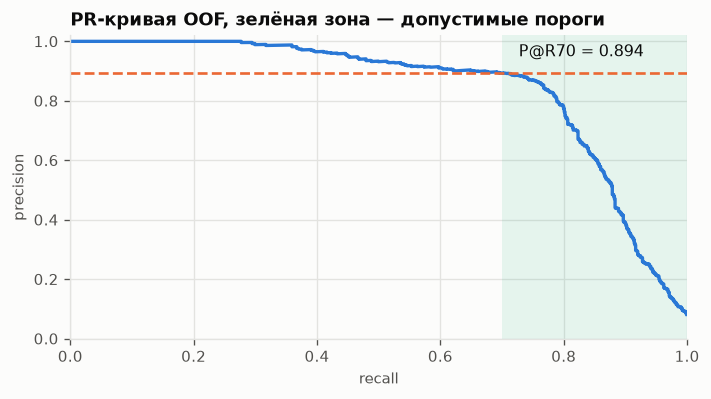

In [13]:
plots.pr_curve(y, oof_final);

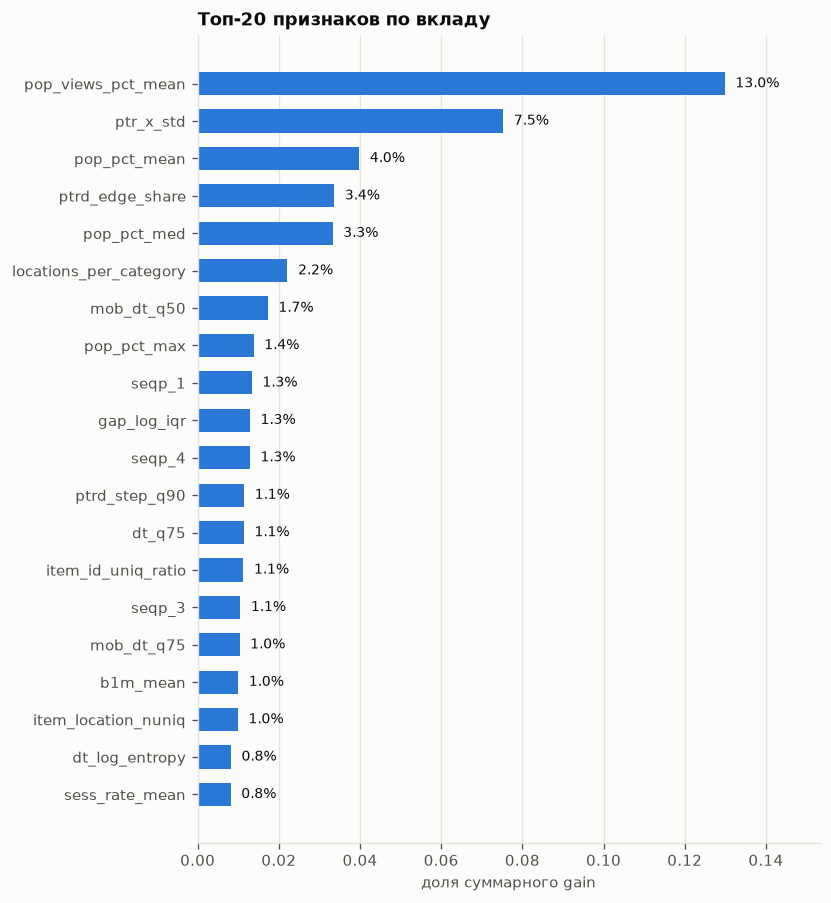

In [14]:
from src.model import feature_gain

gains = sum(
    feature_gain(spec, x, y, seed=config.SEED + offset) for offset in range(3)
).sort_values(ascending=False)
plots.importances(gains, top=20);

## 11. История экспериментов

,experiment,features,P@R70,+/-,ROC-AUC,PR-AUC,R@FPR1%,P@R70 сиды,fc P@R70,шаг
0,B0_baseline_simple,47.0,0.7446,0.0112,0.9273,0.7757,0.6211,0.7621,0.7095,"baseline, 47"
1,ablation_full,NaN,0.7785,0.0114,0.9348,0.7880,0.6129,0.7787,NaN,"ядро, 178"
2,A3_pointer_deep_lgb,353.0,0.7850,0.0124,0.9394,0.7933,0.6307,0.7975,0.7705,"+ курсор, 353"
3,A7_core_nofit_leak,423.0,0.7936,0.0131,0.9416,0.7972,0.6345,0.8067,0.7575,"без утечки в подгонке, 423"
4,A12_core,457.0,0.7917,0.0097,0.9422,0.7993,0.6400,0.8161,0.7692,"+ временной ряд, 457"
5,A15_ua_clients,468.0,0.8034,0.0100,0.9426,0.8018,0.6481,0.8077,0.7740,"+ User-Agent, 468"
6,P7_pop_pct,479.0,0.8894,0.0025,0.9510,0.8363,0.7359,0.8911,0.8836,"+ популярность, 479"
7,final_goss,479.0,0.8937,0.0025,0.9508,0.8380,0.7408,0.8938,0.8957,"+ goss, 479"


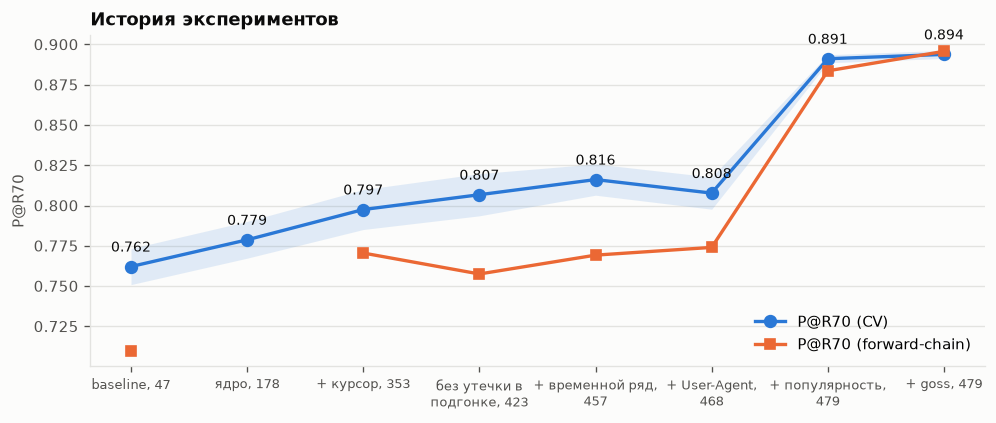

In [15]:
TRACK = {
    "B0_baseline_simple": "baseline, 47",
    "ablation_full": "ядро, 178",
    "A3_pointer_deep_lgb": "+ курсор, 353",
    "A7_core_nofit_leak": "без утечки в подгонке, 423",
    "A12_core": "+ временной ряд, 457",
    "A15_ua_clients": "+ User-Agent, 468",
    "P7_pop_pct": "+ популярность, 479",
    "final_goss": "+ goss, 479",
}
# Колонка "P@R70 сиды" — метрика ранговой смеси пяти валидационных сидов против
# среднего по ним. Бэггинг из 10 сидов, которым считается сам ответ, OOF не
# оценивается: он переобучается на полном train, где размеченной отложенной части уже
# нет. Измеримая часть эффекта усреднения — именно эта колонка.
timeline = report.table(list(TRACK)).assign(шаг=lambda f: f.experiment.map(TRACK))
plots.progression(timeline.dropna(subset=["P@R70"]))
timeline

## 12. Предсказание и файл ответа

Модель переобучается на полном train под 10 сидами, предсказания усредняются в
ранговом пространстве. Итоговый score линейно растягивается в [0, 1] — метрика читает
только порядок.

Сам бэггинг по 10 сидам отдельной OOF-оценки не имеет и иметь не может: он работает на
полном train, отложенной размеченной части при нём не остаётся. Измеримая часть эффекта
— ранговое усреднение валидационных сидов против среднего по ним: 0.8937 → 0.8938 P@R70.

Число сидов выбрано по замеру, а не на глаз. Двадцать независимых OOF-прогонов,
смешиваемых нарастающим итогом: одиночные сиды дают P@R70 в диапазоне 0.8838…0.8973 и
PR-AUC 0.8311…0.8388, к двум сидам разброс уже снят, а дальше кривая плоская — PR-AUC
0.8413 на двух сидах, 0.8419 на пяти, 0.8416 на десяти, 0.8410 на двадцати. Двадцать
сидов не лучше десяти, поэтому берём десять.

In [16]:
from src.submit import BAG_SEEDS, bagged_predictions

# Усреднение по сидам только для боевых предсказаний; валидация идёт на 5 сидах.
scores = bagged_predictions(spec, x, y, dataset.x_test, BAG_SEEDS)
submission = write_submission(dataset.test_ids, scores)

assert len(submission) == len(test), "число строк не совпадает с test.csv"
assert submission.cookie_id.is_unique, "дубликаты cookie_id"
assert set(submission.cookie_id) == set(test.cookie_id), "набор cookie_id не совпадает"
assert submission.score.between(0, 1).all(), "score вне [0, 1]"
assert submission.score.notna().all(), "пропуски в score"

print(submission.head().to_string(index=False))
print(f"\nстрок: {len(submission)}")
print(f"md5 submission.csv: {hashlib.md5(config.SUBMISSION_PATH.read_bytes()).hexdigest()}")

          cookie_id    score
ck_315fb710a0e371e7 0.115694
ck_a76ee3b3e3e522fd 0.799955
ck_94c9a4d382689e82 0.822373
ck_8eaf9509ad9462a0 0.070574
ck_9a88a5a989cb5bc6 0.839349

строк: 4909
md5 submission.csv: aa3cf43cecfcc060128be4769c0c40b9


## 13. Ограничения

- **Метрика шумная.** Разброс P@R70 по сидам ±0.01, по дням до ±0.15. Разница между
  двумя моделями меньше 0.01 ничего не значит, и оценка на скрытом тесте может
  отличаться от OOF на сопоставимую величину.
- **Курсор несёт непропорционально много.** Если источник заполнения `pointer_x`
  изменится (другой сборщик телеметрии, другая версия клиента), качество просядет
  сильнее, чем можно было бы ожидать от одного поля.
- **Мобильный трафик решается хуже веба**, хотя разрыв закрылся: низкий P@R70 внутри
  подгруппы — во многом эффект базовой доли (6.0 % ботов против 9.9 % на вебе). Замер
  потолка — переставить скоры внутри подгруппы в идеальный порядок, сохранив её
  собственные значения, — даёт +0.027 P@R70 для мобильного и +0.095 для веба: основной
  остаток ошибки лежит на вебе, а не на мобильном.
- **Короткие сессии** (≤ 8 событий) — треть кук, но потолок по ним +0.009.
- **Популярность объявлений считается по всей наблюдаемой популяции**, включая
  оцениваемую партию. Меток это не читает и событий вне окна наблюдения не использует,
  но означает, что признак зависит от состава партии: при поштучном скоринге одной куки
  его пришлось бы считать по историческому пулу, а это, как показал строгий протокол,
  другой признак.
- **Обучение на одной неделе.** Сезонность длиннее недели в данных не представлена;
  устойчивость к смене поведения сервисов сбора данных не проверялась.
- **Положительный класс — это известные сервисы.** Модель учится отличать именно их,
  а не автоматизацию вообще; новый сборщик с другим профилем может не ловиться.